In [13]:
import pandas as pd
import numpy as np

In [14]:
df = pd.read_csv('./creditcard.csv')

In [15]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [16]:
X = df.drop(['Time', 'Class'], axis=1).values

In [17]:
X

array([[-1.35980713e+00, -7.27811733e-02,  2.53634674e+00, ...,
         1.33558377e-01, -2.10530535e-02,  1.49620000e+02],
       [ 1.19185711e+00,  2.66150712e-01,  1.66480113e-01, ...,
        -8.98309914e-03,  1.47241692e-02,  2.69000000e+00],
       [-1.35835406e+00, -1.34016307e+00,  1.77320934e+00, ...,
        -5.53527940e-02, -5.97518406e-02,  3.78660000e+02],
       ...,
       [ 1.91956501e+00, -3.01253846e-01, -3.24963981e+00, ...,
         4.45477214e-03, -2.65608286e-02,  6.78800000e+01],
       [-2.40440050e-01,  5.30482513e-01,  7.02510230e-01, ...,
         1.08820735e-01,  1.04532821e-01,  1.00000000e+01],
       [-5.33412522e-01, -1.89733337e-01,  7.03337367e-01, ...,
        -2.41530880e-03,  1.36489143e-02,  2.17000000e+02]],
      shape=(284807, 29))

In [18]:
y = df['Class'].values
y

array([0, 0, 0, ..., 0, 0, 0], shape=(284807,))

In [19]:
normal_idx = np.where(y == 0)[0]
fraud_idx = np.where(y == 1)[0]

normal_idx[ : 5], fraud_idx[ : 5]

(array([0, 1, 2, 3, 4]), array([ 541,  623, 4920, 6108, 6329]))

## Train, Test split

In [60]:
np.random.seed(42)
np.random.shuffle(normal_idx)

train_idx = normal_idx[ : 10000]
test_normal_idx = normal_idx[10000 : 12000]
test_idx = np.concatenate([test_normal_idx, fraud_idx])

X_train = X[train_idx]
X_test = X[test_idx]
y_test = y[test_idx].reshape(-1, 1)

#### Note: Splitting train data with normal transactions implictly states that these are not fraudulent ones.

## Calcualting Eucledian Distance

In [22]:
def standardize(train, test):
    mean = np.mean(train, axis=0)
    std = np.mean(train, axis=0)

    # avoid divide by zero for constant features
    std[std == 0] = 1e-10

    train_scaled = (train - mean) / std
    test_scaled = (test - mean) / std

    return train_scaled, test_scaled

X_train_scaled, X_test_scaled = standardize(X_train, X_test)

In [44]:
def compute_euclidean_distance(A, B):
    A_sq = np.sum(A ** 2, axis=1, keepdims=True)
    B_sq = np.sum(B ** 2, axis=1)

    AB = np.dot(A, B.T)

    distance_sq = A_sq + B_sq - 2 * AB

    # Correct negative zeros from floating point inaccuracies
    distance_sq = np.maximum(distance_sq, 0)

    return np.sqrt(distance_sq)

distance_matrix = compute_euclidean_distance(X_test_scaled, X_train_scaled)

We sum along axis=1 because we need to calculate the a ** 2 and b ** 2 values for each individual transaction. By summing horizontally, we compress all 29 features of a single transaction into one final number, without accidentally mixing the data of two different transactions together.

#### If we pass (X_test, X_train):
Output Shape: (2492, 10000)
Meaning: We have 2,492 rows. Each row represents a single Test Point. Read left to right across a row, you are looking at the distance from that one Test point to all 10,000 Train points.
Why this is correct: Because in the very next step, we want to sort the distances for each test point to find its 5th nearest neighbor. We simply tell NumPy to sort across axis=1 (the row), and we easily get our anomaly scores for our test set.
#### If we passed (X_train, X_test) instead:
Output Shape: (10000, 2492)
Meaning: Now we have 10,000 rows. Each row represents a single Train Point. Read left to right, you are looking at the distance from a known normal transaction to the new test transactions.
Why this is wrong: Sorting this matrix would tell you which Test point is closest to a Train point. That is completely backwards! We don't care about evaluating our historical data; we only care about evaluating the new incoming test transactions.

In [72]:
def KNearestNeighbors(distance_matrix, k):
    sorted_distances = np.sort(distance_matrix, axis=1)

    # get all rows of matrix up to k distances in sorted matrix (distance increases from left to right)
    k_distances = sorted_distances[ : , k-1]

    return k_distances

k = 5
k_distances = KNearestNeighbors(distance_matrix, k)

## Evaluate Predictions

In [73]:
def evaluate_predictions(y_true, y_pred):
    tp = np.sum((y_true == 1) & (y_pred == 1))
    fp = np.sum((y_true == 0) & (y_pred == 1))
    fn = np.sum((y_true == 1) & (y_pred == 0))

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0

    f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

    return precision, recall, f1_score

print("Evaluating KNN Anomaly Detection (k=5)\n" + "-"*40)

for percentile in [80, 85, 90, 95]:
    # Set threshold at the N-th percentile of our scores
    threshold = np.percentile(k_distances, percentile)
    
    # Predict 1 (Fraud) if distance > threshold, else 0
    predictions = (k_distances > threshold).astype(int)
    # print(y_test, predictions)
    precision, recall, f1 = evaluate_predictions(y_test, predictions)
    print(f"Threshold: {percentile}th Percentile (Distance: {threshold:.2f})")
    print(f"Precision: {precision:.3f} | Recall: {recall:.3f} | F1: {f1:.3f}\n")



Evaluating KNN Anomaly Detection (k=5)
----------------------------------------
Threshold: 80th Percentile (Distance: 1852.85)
Precision: 0.197 | Recall: 0.200 | F1: 0.199

Threshold: 85th Percentile (Distance: 2692.96)
Precision: 0.197 | Recall: 0.150 | F1: 0.171

Threshold: 90th Percentile (Distance: 4038.76)
Precision: 0.197 | Recall: 0.100 | F1: 0.133

Threshold: 95th Percentile (Distance: 6489.14)
Precision: 0.197 | Recall: 0.050 | F1: 0.080



Area Under the Precision-Recall Curve (AUPRC): 0.8842


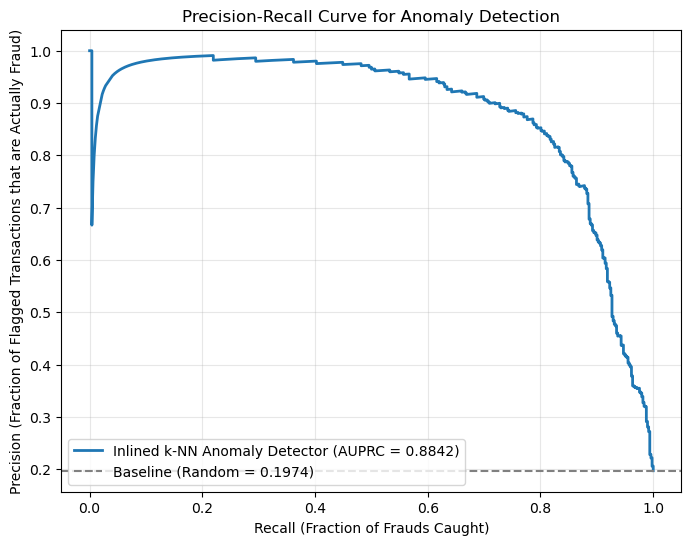

In [74]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, auc

# 1. Get your anomaly scores (Euclidean distances from your test points)
# Assuming 'anomaly_scores' contains the distance to the k-th neighbor
# and 'y_test' contains the actual labels (0 for normal, 1 for fraud)

# 2. Compute Precision and Recall for all possible thresholds
# Note: Since higher distances mean HIGHER probability of fraud, 
# we pass the raw anomaly scores directly.
precision, recall, thresholds = precision_recall_curve(y_test, k_distances)

# 3. Calculate the Area Under the Curve (AUPRC)
auprc_score = auc(recall, precision)
print(f"Area Under the Precision-Recall Curve (AUPRC): {auprc_score:.4f}")

# 4. Plot the AUPRC Curve
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, label=f'Inlined k-NN Anomaly Detector (AUPRC = {auprc_score:.4f})', linewidth=2)

# Plot a baseline horizontal line representing a random classifier
# A random classifier's precision is equal to the proportion of positive cases
baseline = np.sum(y_test == 1) / len(y_test)
plt.axhline(y=baseline, color='gray', linestyle='--', label=f'Baseline (Random = {baseline:.4f})')

plt.xlabel('Recall (Fraction of Frauds Caught)')
plt.ylabel('Precision (Fraction of Flagged Transactions that are Actually Fraud)')
plt.title('Precision-Recall Curve for Anomaly Detection')
plt.legend(loc='lower left')
plt.grid(True, alpha=0.3)
plt.show()